# Credit Card Consumption Case Study


### Business Context

In the modern financial ecosystem, credit cards play a crucial role in enabling seamless transactions and driving consumer spending. Financial institutions collect vast amounts of customer data, including demographics, transaction behavior, and spending patterns.

Understanding credit card consumption behavior helps banks and financial companies:

- Identify high-value customers
- Personalize marketing strategies
- Manage credit risk effectively
- Improve customer retention and profitability

### Problem Statement

- The dataset contains information about customers and their credit card usage. However, the target variable representing credit card consumption is missing for a subset of customers.

- The challenge is to analyze the available data, build a predictive model using customers with known consumption values, and estimate (impute) the missing consumption values for the remaining customers.

### Expected Outcomes:

- Perform exploratory data analysis (EDA) to understand patterns and relationships
- Build a predictive model to estimate credit card consumption
- Validate the model to ensure reliability and accuracy
- Predict missing values of the target variable for customers where consumption data is unavailable

##### Model Evaluation Metric: validate model using Root Mean Square Percentage Error (RMSPE) between the predicted credit card consumption and Actual Credit Consumption.

##### Essential Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

##### Importing Data

In [2]:
customers = pd.read_excel(R"C:\Users\Asus\Downloads\ML Data\CreditCard_CS\Data_Credict_Card\CustomerDemographics.xlsx")
credit = pd.read_excel(R"C:\Users\Asus\Downloads\ML Data\CreditCard_CS\Data_Credict_Card\CreditConsumptionData.xlsx")
behaviour = pd.read_excel(R"C:\Users\Asus\Downloads\ML Data\CreditCard_CS\Data_Credict_Card\CustomerBehaviorData.xlsx")

##### EDA

In [3]:
customers.head()

,ID,account_type,gender,age,Income,Emp_Tenure_Years,Tenure_with_Bank,region_code,NetBanking_Flag,Avg_days_between_transaction
0,19427,current,M,63,MEDIUM,30.1,10,628.0,1,5.0
1,16150,current,M,36,MEDIUM,14.4,10,656.0,0,12.0
2,11749,current,F,28,MEDIUM,4.8,10,314.0,1,13.0
3,11635,current,M,32,MEDIUM,9.6,2,614.0,1,19.0
4,8908,current,M,32,HIGH,12.0,7,750.0,1,18.0


In [4]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            20000 non-null  int64  
 1   account_type                  19999 non-null  object 
 2   gender                        19999 non-null  object 
 3   age                           20000 non-null  int64  
 4   Income                        19999 non-null  object 
 5   Emp_Tenure_Years              20000 non-null  float64
 6   Tenure_with_Bank              20000 non-null  int64  
 7   region_code                   19999 non-null  float64
 8   NetBanking_Flag               20000 non-null  int64  
 9   Avg_days_between_transaction  19997 non-null  float64
dtypes: float64(3), int64(4), object(3)
memory usage: 1.5+ MB


In [5]:
customers.region_code.value_counts() # doesn't quantify/measure but identifies a region with a number/code so should be treated categorically 

region_code
249.0    508
683.0    380
867.0    369
748.0    356
355.0    354
        ... 
484.0      1
436.0      1
608.0      1
398.0      1
857.0      1
Name: count, Length: 210, dtype: int64

In [6]:
customers.NetBanking_Flag.value_counts() #should be treated categorically (binary values 0, 1)

NetBanking_Flag
1    14360
0     5640
Name: count, dtype: int64

In [7]:
customers

,ID,account_type,gender,age,Income,Emp_Tenure_Years,Tenure_with_Bank,region_code,NetBanking_Flag,Avg_days_between_transaction
0,19427,current,M,63,MEDIUM,30.1,10,628.0,1,5.0
1,16150,current,M,36,MEDIUM,14.4,10,656.0,0,12.0
2,11749,current,F,28,MEDIUM,4.8,10,314.0,1,13.0
3,11635,current,M,32,MEDIUM,9.6,2,614.0,1,19.0
4,8908,current,M,32,HIGH,12.0,7,750.0,1,18.0
...,...,...,...,...,...,...,...,...,...,...
19995,1270,current,F,66,MEDIUM,32.2,6,354.0,1,7.0
19996,15992,current,M,53,MEDIUM,19.8,5,809.0,0,14.0
19997,7081,current,F,66,MEDIUM,18.4,1,466.0,0,10.0
19998,6821,current,M,32,LOW,6.0,8,619.0,0,17.0


In [8]:
customers = customers.astype({'NetBanking_Flag' : 'object', 'region_code' : 'object'})

In [9]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            20000 non-null  int64  
 1   account_type                  19999 non-null  object 
 2   gender                        19999 non-null  object 
 3   age                           20000 non-null  int64  
 4   Income                        19999 non-null  object 
 5   Emp_Tenure_Years              20000 non-null  float64
 6   Tenure_with_Bank              20000 non-null  int64  
 7   region_code                   19999 non-null  object 
 8   NetBanking_Flag               20000 non-null  object 
 9   Avg_days_between_transaction  19997 non-null  float64
dtypes: float64(2), int64(3), object(5)
memory usage: 1.5+ MB


In [10]:
behaviour.head()

,ID,cc_cons_apr,dc_cons_apr,cc_cons_may,dc_cons_may,cc_cons_jun,dc_cons_jun,cc_count_apr,cc_count_may,cc_count_jun,...,credit_count_may,debit_count_may,max_credit_amount_may,debit_amount_jun,credit_amount_jun,credit_count_jun,debit_count_jun,max_credit_amount_jun,loan_enq,emi_active
0,17051,2017.46,29066.66,15919.84,2197.00,3752.000,29798.00,1.0,4,35,...,47,20,41860.0,32734.75,80959.00,36,9,171200.0,Y,3448.84
1,11491,7687.00,1308.00,41888.92,2216.92,7060.530,3143.36,2.0,27,50,...,0,8,113367.0,60974.75,495080.00,5,3,15694.0,Y,3812.69
2,7433,9094.46,14825.95,3087.64,769.59,25602.595,1445.00,44.0,8,47,...,2,14,168000.0,425802.96,115707.38,7,58,28058.0,Y,9432.90
3,14606,3126.00,4616.33,8676.80,5923.00,6717.000,18747.00,4.0,30,1,...,45,44,57750.0,25537.91,63606.00,12,0,24459.0,Y,144.61
4,8381,24988.72,10091.23,10132.00,3477.00,4667.000,511.00,2.0,8,5,...,1,2,18405.0,64687.32,62353.35,49,35,31574.0,Y,1887.89


In [11]:
behaviour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 39 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     20000 non-null  int64  
 1   cc_cons_apr            20000 non-null  float64
 2   dc_cons_apr            20000 non-null  float64
 3   cc_cons_may            19999 non-null  float64
 4   dc_cons_may            19999 non-null  float64
 5   cc_cons_jun            20000 non-null  float64
 6   dc_cons_jun            19999 non-null  float64
 7   cc_count_apr           19999 non-null  float64
 8   cc_count_may           20000 non-null  int64  
 9   cc_count_jun           20000 non-null  int64  
 10  dc_count_apr           20000 non-null  int64  
 11  dc_count_may           20000 non-null  int64  
 12  dc_count_jun           20000 non-null  int64  
 13  card_lim               20000 non-null  int64  
 14  personal_loan_active   20000 non-null  int64  
 15  ve

In [12]:
credit.head()

,ID,cc_cons
0,17051,16239.0
1,11491,39002.0
2,7433,21182.0
3,14606,8123.0
4,8381,28282.0


In [13]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       20000 non-null  int64  
 1   cc_cons  15000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 312.6 KB


In [14]:
credit[credit['cc_cons'].isnull()] # total missing cases in the target variable that need to be predicted 

,ID,cc_cons
15000,17591,NaN
15001,13541,NaN
15002,13431,NaN
15003,8687,NaN
15004,14727,NaN
...,...,...
19995,12512,NaN
19996,14224,NaN
19997,18740,NaN
19998,18134,NaN


In [15]:
customers.duplicated(subset='ID').sum()

np.int64(0)

In [16]:
credit.duplicated(subset='ID').sum()

np.int64(0)

In [17]:
behaviour.duplicated(subset='ID').sum()

np.int64(0)

###### Considering the common ID column bw the three tables - merging the 3 tables 

In [18]:
all_customers = pd.merge(customers,behaviour, on = 'ID', how = 'inner')

In [19]:
all_customers = pd.merge(all_customers, credit, on = 'ID', how = 'left') #used left join so that all missing customer details from cc_cons - (test data)

In [20]:
all_customers

,ID,account_type,gender,age,Income,Emp_Tenure_Years,Tenure_with_Bank,region_code,NetBanking_Flag,Avg_days_between_transaction,...,debit_count_may,max_credit_amount_may,debit_amount_jun,credit_amount_jun,credit_count_jun,debit_count_jun,max_credit_amount_jun,loan_enq,emi_active,cc_cons
0,19427,current,M,63,MEDIUM,30.1,10,628.0,1,5.0,...,14,20770.0,44884.90,369000.75,40,96,46088.0,Y,2646.72,NaN
1,16150,current,M,36,MEDIUM,14.4,10,656.0,0,12.0,...,63,78627.0,91073.84,243182.32,7,12,17953.0,Y,5469.79,NaN
2,11749,current,F,28,MEDIUM,4.8,10,314.0,1,13.0,...,82,1260.0,96552.00,35467.00,16,42,41121.0,Y,7207.85,NaN
3,11635,current,M,32,MEDIUM,9.6,2,614.0,1,19.0,...,78,23332.0,18250.00,87204.35,2,10,32003.0,Y,591.34,NaN
4,8908,current,M,32,HIGH,12.0,7,750.0,1,18.0,...,171,41672.0,83525.75,83992.00,21,12,9626.0,Y,2621.39,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,1270,current,F,66,MEDIUM,32.2,6,354.0,1,7.0,...,8,24438.0,153772.21,31284.00,3,38,42872.0,Y,6334.20,NaN
19996,15992,current,M,53,MEDIUM,19.8,5,809.0,0,14.0,...,11,213000.0,18098.47,93108.00,43,11,36747.0,Y,102216.02,NaN
19997,7081,current,F,66,MEDIUM,18.4,1,466.0,0,10.0,...,171,34327.0,32198.63,46800.00,3,38,18810.0,Y,1930.19,NaN
19998,6821,current,M,32,LOW,6.0,8,619.0,0,17.0,...,82,51929.0,27334.14,20201.00,47,80,11443.0,Y,24499.91,NaN


In [21]:
all_customers.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 49 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            20000 non-null  int64  
 1   account_type                  19999 non-null  object 
 2   gender                        19999 non-null  object 
 3   age                           20000 non-null  int64  
 4   Income                        19999 non-null  object 
 5   Emp_Tenure_Years              20000 non-null  float64
 6   Tenure_with_Bank              20000 non-null  int64  
 7   region_code                   19999 non-null  object 
 8   NetBanking_Flag               20000 non-null  object 
 9   Avg_days_between_transaction  19997 non-null  float64
 10  cc_cons_apr                   20000 non-null  float64
 11  dc_cons_apr                   20000 non-null  float64
 12  cc_cons_may                   19999 non-null  float64
 13  d

In [22]:
all_customers.isnull().sum()

ID                                 0
account_type                       1
gender                             1
age                                0
Income                             1
Emp_Tenure_Years                   0
Tenure_with_Bank                   0
region_code                        1
NetBanking_Flag                    0
Avg_days_between_transaction       3
cc_cons_apr                        0
dc_cons_apr                        0
cc_cons_may                        1
dc_cons_may                        1
cc_cons_jun                        0
dc_cons_jun                        1
cc_count_apr                       1
cc_count_may                       0
cc_count_jun                       0
dc_count_apr                       0
dc_count_may                       0
dc_count_jun                       0
card_lim                           0
personal_loan_active               0
vehicle_loan_active                0
personal_loan_closed               1
vehicle_loan_closed                0
i

###### Splitting categorical and continuous variables to treat them separately

In [23]:
numeric = all_customers.select_dtypes(np.number)

In [24]:
text = all_customers.select_dtypes('object')

In [25]:
numeric.describe() # ID column should be removed as it is not useful for further analysis

,ID,age,Emp_Tenure_Years,Tenure_with_Bank,Avg_days_between_transaction,cc_cons_apr,dc_cons_apr,cc_cons_may,dc_cons_may,cc_cons_jun,...,credit_count_may,debit_count_may,max_credit_amount_may,debit_amount_jun,credit_amount_jun,credit_count_jun,debit_count_jun,max_credit_amount_jun,emi_active,cc_cons
count,20000.000000,20000.000000,20000.000000,20000.000000,19997.000000,20000.000000,20000.000000,1.999900e+04,19999.000000,20000.000000,...,20000.00000,20000.000000,2.000000e+04,2.000000e+04,2.000000e+04,20000.000000,20000.000000,2.000000e+04,1.999900e+04,15000.000000
mean,9999.500000,47.672300,15.217250,5.496050,11.044757,17856.990922,8130.453413,1.618836e+04,7702.123897,12135.806021,...,11.91900,40.974850,5.820799e+04,7.812280e+04,7.881693e+04,19.905450,44.529100,5.284985e+04,1.539887e+04,9369.030957
std,5773.647028,30.359771,20.481455,2.870452,5.480552,25158.878234,14572.188829,2.651068e+04,17893.127746,18790.984789,...,16.85576,40.561202,2.085914e+05,2.448983e+05,1.569872e+05,27.055323,35.080453,1.343175e+05,1.202541e+05,7552.997163
min,0.000000,25.000000,0.500000,1.000000,2.000000,253.000000,19.350000,1.570000e+02,22.000000,65.000000,...,0.00000,0.000000,2.500000e-01,5.230000e+00,1.188000e+01,1.000000,0.000000,6.000000e-02,0.000000e+00,610.099000
25%,4999.750000,33.000000,5.100000,3.000000,6.000000,4377.000000,1624.650000,3.635910e+03,1634.260000,2999.075000,...,2.00000,11.000000,2.020225e+04,2.576311e+04,2.492008e+04,4.000000,12.000000,1.896450e+04,1.545940e+03,4808.621700
50%,9999.500000,40.000000,9.900000,6.000000,11.000000,10214.642500,3964.750000,8.635230e+03,3791.720000,6656.800000,...,4.00000,23.000000,3.149650e+04,4.572505e+04,4.618300e+04,7.000000,37.000000,3.025000e+04,3.934660e+03,7408.604400
75%,14999.250000,53.000000,18.000000,8.000000,16.000000,21189.000000,9339.020000,1.865531e+04,8263.590000,14195.727500,...,11.00000,69.000000,5.642100e+04,8.529653e+04,8.602000e+04,21.000000,73.000000,5.344900e+04,9.376390e+03,11518.832800
max,19999.000000,223.000000,203.000000,10.000000,20.000000,441031.330000,229255.000000,1.117246e+06,911223.490000,382914.100000,...,71.00000,171.000000,1.000000e+07,2.642915e+07,6.611953e+06,117.000000,133.000000,5.200000e+06,7.447125e+06,160735.934800


In [26]:
numeric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 43 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            20000 non-null  int64  
 1   age                           20000 non-null  int64  
 2   Emp_Tenure_Years              20000 non-null  float64
 3   Tenure_with_Bank              20000 non-null  int64  
 4   Avg_days_between_transaction  19997 non-null  float64
 5   cc_cons_apr                   20000 non-null  float64
 6   dc_cons_apr                   20000 non-null  float64
 7   cc_cons_may                   19999 non-null  float64
 8   dc_cons_may                   19999 non-null  float64
 9   cc_cons_jun                   20000 non-null  float64
 10  dc_cons_jun                   19999 non-null  float64
 11  cc_count_apr                  19999 non-null  float64
 12  cc_count_may                  20000 non-null  int64  
 13  c

In [27]:
numeric.drop('ID', axis = 1, inplace = True)

In [28]:

def continuous_summary(x):
    total_n = x.shape[0] #total rows
    total_miss = x.isna().sum() #total missings
    miss_perc = total_miss/total_n * 100 #missing %
    min_val = min(x)
    P1 = x.quantile(0.01)
    P25 = x.quantile(0.25)
    P50 = x.quantile(0.50)
    P75 = x.quantile(0.75)
    P90 = x.quantile(0.90)
    P99 = x.quantile(0.99)
    P100 = x.quantile(1)
    max_val = max(x)
    IQR = P75 - P25
    uc = P25 - 1.5 * IQR
    lc = P75 + 1.5 * IQR

    return pd.Series([x.dtype, x.nunique(), x.count(), total_n, total_miss, miss_perc, x.sum(), x.mean(), x.var(), x.std(), 
                    lc, uc, min_val, P1, P25, P50, P75, P90, P99, P100, max_val],
                     index = ['dtype', 'unique','n', 'total', 'total missing', 'missing%', 'sum', 'mean', 'var', 'std', 'UC', 'LC', 'min', 
                              'P1', 'P25', 'P50', 'P75', 'P90', 'P99', 'P100', 'max_val'])


In [29]:
numeric.apply(continuous_summary)

,age,Emp_Tenure_Years,Tenure_with_Bank,Avg_days_between_transaction,cc_cons_apr,dc_cons_apr,cc_cons_may,dc_cons_may,cc_cons_jun,dc_cons_jun,...,credit_count_may,debit_count_may,max_credit_amount_may,debit_amount_jun,credit_amount_jun,credit_count_jun,debit_count_jun,max_credit_amount_jun,emi_active,cc_cons
dtype,int64,float64,int64,float64,float64,float64,float64,float64,float64,float64,...,int64,int64,float64,float64,float64,int64,int64,float64,float64,float64
unique,43,270,10,19,8459,3861,8504,4053,7347,3019,...,31,57,5299,8632,8311,39,66,5833,5940,14998
n,20000,20000,20000,19997,20000,20000,19999,19999,20000,19999,...,20000,20000,20000,20000,20000,20000,20000,20000,19999,15000
total,20000,20000,20000,20000,20000,20000,20000,20000,20000,20000,...,20000,20000,20000,20000,20000,20000,20000,20000,20000,20000
total missing,0,0,0,3,0,0,1,1,0,1,...,0,0,0,0,0,0,0,0,1,5000
missing%,0.0,0.0,0.0,0.015,0.0,0.0,0.005,0.005,0.0,0.005,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.005,25.0
sum,953446,304345.0,109921,220862.0,357139818.44,162609068.27,323751105.97,154034775.82,242716120.41,142187057.12,...,238380,819497,1164159702.76,1562455943.19,1576338552.15,398109,890582,1056996951.42,307961976.6,140535464.3485
mean,47.6723,15.21725,5.49605,11.044757,17856.990922,8130.453413,16188.364717,7702.123897,12135.806021,7109.708341,...,11.919,40.97485,58207.985138,78122.797159,78816.927608,19.90545,44.5291,52849.847571,15398.868773,9369.030957
var,921.715698,419.489979,8.239496,30.036454,632969153.988081,212348687.260088,702816238.690252,320164020.540491,353101109.3296,177260881.388225,...,284.116645,1645.211078,43510356594.345329,59975181619.710739,24644994076.81049,731.99051,1230.638185,18041197550.945335,14461042739.004181,57047766.148073
std,30.359771,20.481455,2.870452,5.480552,25158.878234,14572.188829,26510.681596,17893.127746,18790.984789,13313.935609,...,16.85576,40.561202,208591.362703,244898.308732,156987.241764,27.055323,35.080453,134317.525107,120254.075769,7552.997163


In [30]:
numeric.skew()

age                              4.400724
Emp_Tenure_Years                 5.210224
Tenure_with_Bank                 0.003167
Avg_days_between_transaction    -0.007326
cc_cons_apr                      4.779839
dc_cons_apr                      7.040999
cc_cons_may                     10.908878
dc_cons_may                     23.648366
cc_cons_jun                      6.185617
dc_cons_jun                      6.412228
cc_count_apr                     4.400983
cc_count_may                     7.505764
cc_count_jun                     7.173341
dc_count_apr                     1.113107
dc_count_may                     1.513277
dc_count_jun                     0.720989
card_lim                         0.450068
personal_loan_active             0.000000
vehicle_loan_active              0.000000
personal_loan_closed             0.000000
vehicle_loan_closed              0.000000
investment_1                    11.875443
investment_2                     5.505656
investment_3                     4

###### since most columns are heavy tailed (positive) percentile capping is a more appropriate outlier treatment than IQR
###### Outlier Treatment - Percentile Method 

In [31]:
numeric = numeric.apply( lambda x: x.clip(lower = x.quantile(0.01),upper = x.quantile(0.99)))

In [32]:
numeric.apply(continuous_summary)

,age,Emp_Tenure_Years,Tenure_with_Bank,Avg_days_between_transaction,cc_cons_apr,dc_cons_apr,cc_cons_may,dc_cons_may,cc_cons_jun,dc_cons_jun,...,credit_count_may,debit_count_may,max_credit_amount_may,debit_amount_jun,credit_amount_jun,credit_count_jun,debit_count_jun,max_credit_amount_jun,emi_active,cc_cons
dtype,int64,float64,int64,float64,float64,float64,float64,float64,float64,float64,...,int64,int64,float64,float64,float64,int64,int64,float64,float64,float64
unique,41,246,10,19,8302,3789,8345,3972,7205,2951,...,30,56,5196,8476,8150,39,65,5718,5832,14700
n,20000,20000,20000,19997,20000,20000,19999,19999,20000,19999,...,20000,20000,20000,20000,20000,20000,20000,20000,19999,15000
total,20000,20000,20000,20000,20000,20000,20000,20000,20000,20000,...,20000,20000,20000,20000,20000,20000,20000,20000,20000,20000
total missing,0,0,0,3,0,0,1,1,0,1,...,0,0,0,0,0,0,0,0,1,5000
missing%,0.0,0.0,0.0,0.015,0.0,0.0,0.005,0.005,0.0,0.005,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.005,25.0
sum,953579,294931.2,109921,220862.0,346146525.37,152855585.51,311485406.43,143817481.99,232619464.114999,135690695.56,...,238356,819575,1012022855.42,1425114478.53,1456158777.81,398109,889961,956316532.8,201720730.94,138666847.5988
mean,47.67895,14.74656,5.49605,11.044757,17307.326269,7642.779275,15575.049074,7191.233661,11630.973206,6784.874022,...,11.9178,40.97875,50601.142771,71255.723926,72807.93889,19.90545,44.49805,47815.82664,10086.540874,9244.456507
var,918.774516,290.375592,8.239496,30.036454,448621506.394322,109330220.730954,416193282.644559,106682126.081438,215769141.419009,112562775.406872,...,283.976042,1644.895343,3507827831.613968,6657940604.97055,7247698713.828236,731.99051,1225.422367,3287792926.408168,453830722.744925,44396105.024206
std,30.311294,17.040411,2.870452,5.480552,21180.687109,10456.109254,20400.815735,10328.703988,14689.082389,10609.560566,...,16.851589,40.557309,59226.918134,81596.204599,85133.417139,27.055323,35.006033,57339.279089,21303.303095,6663.040224


In [33]:
numeric.skew() #Outlier treatment helped get rid of extreme skewness

age                             4.399664
Emp_Tenure_Years                3.672164
Tenure_with_Bank                0.003167
Avg_days_between_transaction   -0.007326
cc_cons_apr                     2.716002
dc_cons_apr                     3.020225
cc_cons_may                     2.998549
dc_cons_may                     3.430149
cc_cons_jun                     2.920322
dc_cons_jun                     3.826128
cc_count_apr                    4.400983
cc_count_may                    1.246057
cc_count_jun                    0.706593
dc_count_apr                    1.014951
dc_count_may                    1.477989
dc_count_jun                    0.720989
card_lim                        0.371109
personal_loan_active            0.000000
vehicle_loan_active             0.000000
personal_loan_closed            0.000000
vehicle_loan_closed             0.000000
investment_1                    5.599893
investment_2                    2.797431
investment_3                    4.078252
investment_4    

<Axes: xlabel='cc_cons', ylabel='Count'>

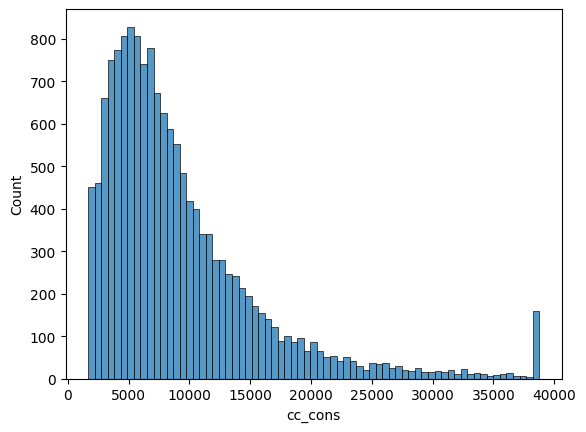

In [34]:
sns.histplot(numeric['cc_cons'])

###### Missing Values Treatment

In [35]:
missing_summary = numeric.isna().agg(['sum', 'mean']).T.rename(columns = {'sum' : 'Total Missings', 'mean' : '%'}) 

In [36]:
missing_summary['%'] = missing_summary['%'] * 100

In [37]:
missing_summary ### Since % of missings values is lower than the standard 5-7% missing will replacing the missing value with mean

,Total Missings,%
age,0.0,0.000
Emp_Tenure_Years,0.0,0.000
Tenure_with_Bank,0.0,0.000
Avg_days_between_transaction,3.0,0.015
cc_cons_apr,0.0,0.000
dc_cons_apr,0.0,0.000
cc_cons_may,1.0,0.005
dc_cons_may,1.0,0.005
cc_cons_jun,0.0,0.000
dc_cons_jun,1.0,0.005


In [38]:
dropped_target = numeric['cc_cons']

In [39]:
numeric2 = numeric.drop('cc_cons', axis = 1)  #### Separating 'cc_cons' for further missing values treatment as missing vals (5000, 25%) in this col will serve as test data and need to be untouched'

In [40]:
numeric2 = numeric2.fillna(numeric2.mean())

In [41]:
numeric2.info() ## Ensuring all columns are non-null

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           20000 non-null  int64  
 1   Emp_Tenure_Years              20000 non-null  float64
 2   Tenure_with_Bank              20000 non-null  int64  
 3   Avg_days_between_transaction  20000 non-null  float64
 4   cc_cons_apr                   20000 non-null  float64
 5   dc_cons_apr                   20000 non-null  float64
 6   cc_cons_may                   20000 non-null  float64
 7   dc_cons_may                   20000 non-null  float64
 8   cc_cons_jun                   20000 non-null  float64
 9   dc_cons_jun                   20000 non-null  float64
 10  cc_count_apr                  20000 non-null  float64
 11  cc_count_may                  20000 non-null  int64  
 12  cc_count_jun                  20000 non-null  int64  
 13  d

#### Categorical Variable Treatment (Missing Value Imputation + Dummy Variables)

In [42]:
text.describe()  #loan_enq column contains same Y for each and every customer which does not explain too much so should be dropped 

,account_type,gender,Income,region_code,NetBanking_Flag,loan_enq
count,19999,19999,19999,19999.0,20000,19998
unique,2,2,3,210.0,2,1
top,current,M,MEDIUM,249.0,1,Y
freq,16925,17287,12774,508.0,14360,19998


In [43]:
text.drop('loan_enq', axis = 1, inplace = True)

In [44]:
text.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   account_type     19999 non-null  object
 1   gender           19999 non-null  object
 2   Income           19999 non-null  object
 3   region_code      19999 non-null  object
 4   NetBanking_Flag  20000 non-null  object
dtypes: object(5)
memory usage: 781.4+ KB


In [45]:
text.isna().sum()

account_type       1
gender             1
Income             1
region_code        1
NetBanking_Flag    0
dtype: int64

In [46]:
text.mode()

,account_type,gender,Income,region_code,NetBanking_Flag
0,current,M,MEDIUM,249.0,1


In [47]:
text = text.fillna(text.mode().iloc[0])

C:\Users\Asus\AppData\Local\Temp\ipykernel_5108\3960672466.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  text = text.fillna(text.mode().iloc[0])


In [48]:
text.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   account_type     20000 non-null  object 
 1   gender           20000 non-null  object 
 2   Income           20000 non-null  object 
 3   region_code      20000 non-null  float64
 4   NetBanking_Flag  20000 non-null  int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 781.4+ KB


In [49]:
text.astype('object')

,account_type,gender,Income,region_code,NetBanking_Flag
0,current,M,MEDIUM,628.0,1
1,current,M,MEDIUM,656.0,0
2,current,F,MEDIUM,314.0,1
3,current,M,MEDIUM,614.0,1
4,current,M,HIGH,750.0,1
...,...,...,...,...,...
19995,current,F,MEDIUM,354.0,1
19996,current,M,MEDIUM,809.0,0
19997,current,F,MEDIUM,466.0,0
19998,current,M,LOW,619.0,0


In [50]:
text['Income'].value_counts() #Ordinal Categorical Variable i.e. it has a sequence/order in its nature 

Income
MEDIUM    12775
LOW        5612
HIGH       1613
Name: count, dtype: int64

In [51]:
text['Income'] = text['Income'].map({'LOW': 1,'MEDIUM': 2,'HIGH': 3})

In [52]:
text.columns

Index(['account_type', 'gender', 'Income', 'region_code', 'NetBanking_Flag'], dtype='object')

In [53]:
text.NetBanking_Flag.value_counts()

NetBanking_Flag
1    14360
0     5640
Name: count, dtype: int64

In [54]:
text.region_code.value_counts()

region_code
249.0    509
683.0    380
867.0    369
748.0    356
355.0    354
        ... 
484.0      1
436.0      1
608.0      1
398.0      1
857.0      1
Name: count, Length: 210, dtype: int64

In [55]:
text = pd.get_dummies(text, columns = ['account_type', 'gender'], drop_first = True, prefix = ['acct', 'gen'])

In [56]:
text.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Income           20000 non-null  int64  
 1   region_code      20000 non-null  float64
 2   NetBanking_Flag  20000 non-null  int64  
 3   acct_saving      20000 non-null  bool   
 4   gen_M            20000 non-null  bool   
dtypes: bool(2), float64(1), int64(2)
memory usage: 507.9 KB


In [57]:
text['region_code'].astype('object')

0        628.0
1        656.0
2        314.0
3        614.0
4        750.0
         ...  
19995    354.0
19996    809.0
19997    466.0
19998    619.0
19999    882.0
Name: region_code, Length: 20000, dtype: object

In [58]:
text.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Income           20000 non-null  int64  
 1   region_code      20000 non-null  float64
 2   NetBanking_Flag  20000 non-null  int64  
 3   acct_saving      20000 non-null  bool   
 4   gen_M            20000 non-null  bool   
dtypes: bool(2), float64(1), int64(2)
memory usage: 507.9 KB


In [59]:
text[['region_code', 'NetBanking_Flag']] = text[['region_code', 'NetBanking_Flag']].astype('category')

In [60]:
text.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Income           20000 non-null  int64   
 1   region_code      20000 non-null  category
 2   NetBanking_Flag  20000 non-null  category
 3   acct_saving      20000 non-null  bool    
 4   gen_M            20000 non-null  bool    
dtypes: bool(2), category(2), int64(1)
memory usage: 263.9 KB


In [61]:
text = pd.get_dummies(text, columns = ['region_code', 'NetBanking_Flag'], drop_first = True)

In [62]:
text

,Income,acct_saving,gen_M,region_code_233.0,region_code_243.0,region_code_244.0,region_code_245.0,region_code_247.0,region_code_248.0,region_code_249.0,...,region_code_958.0,region_code_963.0,region_code_964.0,region_code_965.0,region_code_966.0,region_code_968.0,region_code_969.0,region_code_970.0,region_code_974.0,NetBanking_Flag_1
0,2,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,2,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,3,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,2,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
19996,2,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19997,2,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19998,1,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [63]:
text.astype(int)

,Income,acct_saving,gen_M,region_code_233.0,region_code_243.0,region_code_244.0,region_code_245.0,region_code_247.0,region_code_248.0,region_code_249.0,...,region_code_958.0,region_code_963.0,region_code_964.0,region_code_965.0,region_code_966.0,region_code_968.0,region_code_969.0,region_code_970.0,region_code_974.0,NetBanking_Flag_1
0,2,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,2,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,3,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
19996,2,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19997,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19998,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [64]:
text.columns = text.columns.str.replace('.0', '', regex=False)

In [65]:
text.astype(int).head()

,Income,acct_saving,gen_M,region_code_233,region_code_243,region_code_244,region_code_245,region_code_247,region_code_248,region_code_249,...,region_code_958,region_code_963,region_code_964,region_code_965,region_code_966,region_code_968,region_code_969,region_code_970,region_code_974,NetBanking_Flag_1
0,2,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,2,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,3,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


#### Data Compilation & Splitting

In [66]:
Customers_compiled = pd.concat([text, numeric2], axis = 1)
Customers_compiled = pd.concat([Customers_compiled, dropped_target], axis = 1 )

In [67]:
train_data = Customers_compiled[~Customers_compiled.cc_cons.isna()] #dataset when cc_cons/target column data is present - used for training
predict_data = Customers_compiled[Customers_compiled.cc_cons.isna()] #target data which needs to be predicted (missing)(5000)

In [68]:
x = train_data.drop('cc_cons', axis=1)

In [69]:
y = train_data['cc_cons']

In [70]:
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size = 0.3, random_state = 223)

In [71]:
train_x = train_x.astype('float')

In [72]:
vif_data = pd.DataFrame()
vif_data["Feature"] = train_x.columns
vif_data["VIF"] = [variance_inflation_factor(train_x.values, i) for i in range(train_x.shape[1])]

C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [74]:
vif_data[vif_data['VIF'] > 5]

,Feature,VIF


In [75]:
vif_data

,Feature,VIF
0,Income,1.021889
1,acct_saving,1.027554
2,gen_M,1.023623
3,region_code_233,2.390957
4,region_code_243,1.840791
...,...,...
249,credit_amount_jun,1.024322
250,credit_count_jun,1.021513
251,debit_count_jun,1.027522
252,max_credit_amount_jun,1.022147


In [76]:
scaler = StandardScaler()

train_x_scaled = scaler.fit_transform(train_x)
test_x_scaled = scaler.transform(test_x)

### Training Linear Regression Model + Predictions 

In [77]:
model = LinearRegression()
model.fit(train_x_scaled, train_y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [78]:
train_pred = model.predict(train_x_scaled)
test_pred = model.predict(test_x_scaled)

#### Model Performance & Evaluation

In [79]:
train_rmse = np.sqrt(mean_squared_error(train_y, train_pred))
test_rmse = np.sqrt(mean_squared_error(test_y, test_pred))

In [80]:
train_rmse # on average the model’s predictions deviate from actual credit card consumption by about Rs 2911

np.float64(2911.2923650393586)

In [81]:
test_rmse #difference between train and test RMSE (Rs 2) indicates that the model generalizes well and is not overfitting.

np.float64(2913.848633471434)

In [82]:
def rmspe(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

In [83]:
train_rmspe = rmspe(train_y, train_pred)
test_rmspe = rmspe(test_y, test_pred)

In [84]:
print(train_rmspe, test_rmspe)

0.27994256886713903 0.3058200481206644


In [85]:
train_r2 = r2_score(train_y, train_pred)
test_r2 = r2_score(test_y, test_pred)
print(train_r2, test_r2)

0.8097573074741871 0.8070270657676133


##### Final Predictions

In [86]:
predict_data_x = predict_data.drop('cc_cons', axis=1)
final_predictions = model.predict(predict_data_x)
final_predictions

C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


array([9.23207901e+07, 9.77555563e+07, 2.36514689e+08, ...,
       6.95351485e+07, 1.09386531e+08, 2.10687182e+08], shape=(5000,))

In [87]:
coefficients = pd.DataFrame({'Feature': x.columns,'Coefficient': model.coef_})

In [88]:
coefficients

,Feature,Coefficient
0,Income,42.082893
1,acct_saving,4.853487
2,gen_M,-32.891746
3,region_code_233,-2.590391
4,region_code_243,-15.930502
...,...,...
249,credit_amount_jun,18.498723
250,credit_count_jun,52.276932
251,debit_count_jun,-11.981211
252,max_credit_amount_jun,-12.245122


In [91]:
coefficients.sort_values(by="Coefficient", ascending=False).head(10)

,Feature,Coefficient
219,cc_cons_may,3444.889351
217,cc_cons_apr,3343.290216
221,cc_cons_jun,2474.561254
218,dc_cons_apr,1855.943254
220,dc_cons_may,1833.410011
111,region_code_619,161.132075
133,region_code_693,73.213031
128,region_code_658,56.055211
250,credit_count_jun,52.276932
207,region_code_966,52.158184


#### These Top 10 Positive coefficients suggest:
- Past credit card usage (cc_cons_apr/may/jun ) is the strongest predictor of future consumption.
- Customers who spend more via debit cards (dc_cons_may) also tend to have higher overall consumption behavior.
- More frequent credit activity (credit_count_jun)slightly increases predicted consumption.
- Certain geographic regions (region code - 966, 619, 693, 658) show higher spending tendencies.

In [92]:
coefficients.sort_values(by="Coefficient").head(10)

,Feature,Coefficient
162,region_code_814,-68.172611
185,region_code_907,-64.608044
19,region_code_269,-62.366701
15,region_code_265,-59.632833
182,region_code_887,-59.603680
93,region_code_558,-59.434939
164,region_code_823,-58.074888
21,region_code_274,-56.551692
248,debit_amount_jun,-56.108397
94,region_code_566,-56.094451


#### Top 10 Negative Coefficients suggest: 
- Certain regions are associated with lower credit consumption patterns suggesting strong geographic segmentation in customer behavior.
- Higher debit outflow in June slightly reduces predicted credit consumption.

### CONCLUSION: 

#### The model reveals that historical spending behavior is the strongest predictor of credit card consumption. Features such as past credit card and debit card usage across multiple months show the highest positive impact on predicted consumption, indicating strong behavioral consistency among customers.

#### In contrast, regional variables dominate the negative coefficients, suggesting significant geographic variation in spending patterns. Certain regions are associated with lower credit consumption levels, highlighting potential segmentation opportunities.